In [1]:
new_contour_dir =  "/srv/storage/talc@storage4.nancy/multispeech/corpus/speech_production/iadi/Yves_Laprie/Contours/ArtSpeech_Database_2"
old_contour_dir = "/srv/storage/talc@storage4.nancy/multispeech/corpus/speech_production/iadi/ArtSpeech_Database_2"

In [2]:
import os
from pathlib import Path
from collections import defaultdict

In [3]:
def get_subject_sessions(base_dir):
    """
    Get dictionary of subjects and their sessions from a directory.
    Returns: dict with subject as key and set of sessions as value
    """
    subject_sessions = defaultdict(set)
    
    if not os.path.exists(base_dir):
        print(f"Directory does not exist: {base_dir}")
        return subject_sessions
    
    for subject in os.listdir(base_dir):
        subject_path = os.path.join(base_dir, subject)
        if os.path.isdir(subject_path):
            # Look for sessions in this subject directory
            for session in os.listdir(subject_path):
                session_path = os.path.join(subject_path, session)
                if os.path.isdir(session_path):
                    subject_sessions[subject].add(session)
    
    return subject_sessions

In [4]:
# Get subject-session mappings from both directories
print("Scanning old contour directory...")
old_sessions = get_subject_sessions(old_contour_dir)
print(f"Found {len(old_sessions)} subjects in old directory\n")

print("Scanning new contour directory...")
new_sessions = get_subject_sessions(new_contour_dir)
print(f"Found {len(new_sessions)} subjects in new directory\n")

Scanning old contour directory...
Found 6 subjects in old directory

Scanning new contour directory...
Found 5 subjects in new directory



In [5]:
# Compare subjects
all_subjects = set(old_sessions.keys()) | set(new_sessions.keys())
old_only = set(old_sessions.keys()) - set(new_sessions.keys())
new_only = set(new_sessions.keys()) - set(old_sessions.keys())
common_subjects = set(old_sessions.keys()) & set(new_sessions.keys())

print("="*80)
print("SUBJECT COMPARISON")
print("="*80)
print(f"Subjects only in OLD directory: {sorted(old_only) if old_only else 'None'}")
print(f"Subjects only in NEW directory: {sorted(new_only) if new_only else 'None'}")
print(f"Common subjects: {len(common_subjects)}")
print()

SUBJECT COMPARISON
Subjects only in OLD directory: ['1796']
Subjects only in NEW directory: None
Common subjects: 5



In [7]:
# Compare sessions for common subjects
print("="*80)
print("SESSION COMPARISON FOR COMMON SUBJECTS")
print("="*80)

mismatches = []
for subject in sorted(common_subjects):
    old_sess = old_sessions[subject]
    new_sess = new_sessions[subject]
    
    missing_in_new = old_sess - new_sess
    extra_in_new = new_sess - old_sess
    
    if missing_in_new or extra_in_new:
        mismatches.append(subject)
        print(f"\n Subject: {subject}")
        print(f"   Old sessions ({len(old_sess)}): {sorted(old_sess)}")
        print(f"   New sessions ({len(new_sess)}): {sorted(new_sess)}")
        if missing_in_new:
            print(f"    Missing in NEW: {sorted(missing_in_new)}")
        if extra_in_new:
            print(f"   Extra in NEW: {sorted(extra_in_new)}")
    else:
        print(f"✓ Subject: {subject} - Sessions match ({len(old_sess)} sessions)")

print(f"\n{'='*80}")
print(f"SUMMARY")
print(f"{'='*80}")
print(f"Total subjects checked: {len(common_subjects)}")
print(f"Subjects with matching sessions: {len(common_subjects) - len(mismatches)}")
print(f"Subjects with session mismatches: {len(mismatches)}")
if mismatches:
    print(f"Subjects with mismatches: {mismatches}")

SESSION COMPARISON FOR COMMON SUBJECTS
✓ Subject: 1775 - Sessions match (38 sessions)

 Subject: 1777
   Old sessions (27): ['S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S27', 'S28', 'S29', 'S30', 'S31', 'S32', 'S33', 'S34', 'S35', 'S36', 'S37', 'S38', 'S39']
   New sessions (22): ['S16', 'S17', 'S18', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S27', 'S28', 'S29', 'S30', 'S31', 'S32', 'S33', 'S34', 'S35', 'S36', 'S38', 'S39']
    Missing in NEW: ['S13', 'S14', 'S15', 'S19', 'S37']

 Subject: 1789
   Old sessions (33): ['S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S27', 'S28', 'S29', 'S30', 'S31', 'S32', 'S33', 'S34', 'S35', 'S36', 'S37', 'S38', 'S39', 'S40', 'S41', 'S42', 'S43', 'S44']
   New sessions (23): ['S15', 'S21', 'S22', 'S23', 'S24', 'S27', 'S28', 'S29', 'S30', 'S31', 'S32', 'S33', 'S34', 'S35', 'S36', 'S37', 'S38', 'S39', 'S40', 'S41', 'S42', 'S43', 'S44']

In [14]:
def check_contours_in_session(session_path):
    """
    Check if a session directory contains contour files in the 'contour' subfolder.
    Returns: (has_contours, contour_count, file_list)
    """
    contour_subfolder = os.path.join(session_path, 'contours')
    
    if not os.path.exists(contour_subfolder):
        return False, 0, []
    
    contour_files = []
    for file in os.listdir(contour_subfolder):
        file_path = os.path.join(contour_subfolder, file)
        # Check for files (not directories)
        if os.path.isfile(file_path):
            contour_files.append(file)
    
    return len(contour_files) > 0, len(contour_files), contour_files

In [23]:
# Find sessions in NEW directory that have contours and check if they exist in OLD directory
print("\n" + "="*80)
print("CHECKING SESSIONS WITH CONTOURS IN NEW DIRECTORY")
print("="*80)

sessions_only_in_new = []  # Sessions that exist in new but not in old
sessions_both_dirs = []    # Sessions that exist in both directories

for subject in sorted(new_sessions.keys()):
    new_sess = new_sessions[subject]
    old_sess = old_sessions.get(subject, set())
    
    subject_has_output = False
    
    for session in sorted(new_sess):
        # Check if this session in NEW directory has contours
        new_session_path = os.path.join(new_contour_dir, subject, session)
        new_has_contours, new_count, new_files = check_contours_in_session(new_session_path)
        
        # Only process if NEW session has contours
        if new_has_contours:
            if not subject_has_output:
                print(f"\n{'='*60}")
                print(f"Subject: {subject}")
                print(f"{'='*60}")
                subject_has_output = True
            
            # Check if this session also exists in OLD directory
            if session in old_sess:
                # Session exists in both - check if OLD also has contours
                old_session_path = os.path.join(old_contour_dir, subject, session)
                old_has_contours, old_count, old_files = check_contours_in_session(old_session_path)
                
                if old_has_contours:
                    sessions_both_dirs.append((subject, session, new_count, old_count))
                    print(f"  ✓ Session: {session}")
                    print(f"    - NEW: {new_count} contour files")
                    print(f"    - OLD: {old_count} contour files")
                    print(f"    - Status: EXISTS IN BOTH with contours")
                else:
                    sessions_both_dirs.append((subject, session, new_count, 0))
                    print(f"  ⚠️  Session: {session}")
                    print(f"    - NEW: {new_count} contour files")
                    print(f"    - OLD: NO CONTOURS (session exists but no contours)")
                    print(f"    - Status: Session in both but OLD has NO contours")
            else:
                # Session only exists in NEW directory
                sessions_only_in_new.append((subject, session, new_count))
                print(f"  ➕ Session: {session}")
                print(f"    - NEW: {new_count} contour files")
                print(f"    - OLD: Session does NOT exist")
                print(f"    - Status: ONLY IN NEW directory")

print(f"\n{'='*80}")
print(f"FINAL SUMMARY")
print(f"{'='*80}")
print(f"Sessions with contours ONLY in NEW directory: {len(sessions_only_in_new)}")
print(f"Sessions with contours in BOTH directories: {len(sessions_both_dirs)}")

if sessions_only_in_new:
    print(f"\n--- Sessions ONLY in NEW directory ({len(sessions_only_in_new)} total) ---")
    for subject, session, count in sessions_only_in_new:
        print(f"  • {subject}/{session}: {count} files")

if sessions_both_dirs:
    print(f"\n--- Sessions in BOTH directories ({len(sessions_both_dirs)} total) ---")
    for subject, session, new_count, old_count in sessions_both_dirs:
        if old_count == 0:
            print(f"  ⚠️  {subject}/{session}: NEW={new_count} files, OLD=NO CONTOURS")
        else:
            print(f"  ✓ {subject}/{session}: NEW={new_count} files, OLD={old_count} files")


CHECKING SESSIONS WITH CONTOURS IN NEW DIRECTORY

Subject: 1775
  ✓ Session: S10
    - NEW: 10 contour files
    - OLD: 10 contour files
    - Status: EXISTS IN BOTH with contours
  ✓ Session: S11
    - NEW: 46 contour files
    - OLD: 46 contour files
    - Status: EXISTS IN BOTH with contours
  ✓ Session: S12
    - NEW: 118 contour files
    - OLD: 118 contour files
    - Status: EXISTS IN BOTH with contours
  ✓ Session: S13
    - NEW: 261 contour files
    - OLD: 261 contour files
    - Status: EXISTS IN BOTH with contours
  ✓ Session: S14
    - NEW: 117 contour files
    - OLD: 117 contour files
    - Status: EXISTS IN BOTH with contours
  ✓ Session: S15
    - NEW: 216 contour files
    - OLD: 216 contour files
    - Status: EXISTS IN BOTH with contours
  ✓ Session: S16
    - NEW: 163 contour files
    - OLD: 163 contour files
    - Status: EXISTS IN BOTH with contours
  ✓ Session: S17
    - NEW: 298 contour files
    - OLD: 298 contour files
    - Status: EXISTS IN BOTH with cont

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def read_roi_file(roi_file_path):
    """
    Read an ROI file and return the contour coordinates.
    Assumes ROI file format contains x,y coordinates.
    """
    try:
        # Try to read as text file with coordinates
        with open(roi_file_path, 'r') as f:
            lines = f.readlines()
        
        # Parse coordinates (assuming format like "x,y" or "x y" or just numbers)
        coords = []
        for line in lines:
            line = line.strip()
            if line and not line.startswith('#'):  # Skip empty lines and comments
                # Try different separators
                if ',' in line:
                    parts = line.split(',')
                elif '\t' in line:
                    parts = line.split('\t')
                else:
                    parts = line.split()
                
                if len(parts) >= 2:
                    try:
                        x = float(parts[0])
                        y = float(parts[1])
                        coords.append([x, y])
                    except ValueError:
                        continue
        
        return np.array(coords) if coords else None
    except Exception as e:
        print(f"Error reading file {roi_file_path}: {e}")
        return None

def display_roi_contour(roi_file_path, title=None):
    """
    Read and display an ROI contour.
    """
    coords = read_roi_file(roi_file_path)
    
    if coords is None or len(coords) == 0:
        print(f"Could not read coordinates from {roi_file_path}")
        return
    
    plt.figure(figsize=(10, 8))
    plt.plot(coords[:, 0], coords[:, 1], 'b-', linewidth=2, label='Contour')
    plt.plot(coords[:, 0], coords[:, 1], 'ro', markersize=3, label='Points')
    
    # Close the contour if it's not already closed
    if not np.allclose(coords[0], coords[-1]):
        plt.plot([coords[-1, 0], coords[0, 0]], [coords[-1, 1], coords[0, 1]], 'b--', linewidth=1, alpha=0.5)
    
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.title(title or f'ROI Contour\n{os.path.basename(roi_file_path)}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print(f"Contour has {len(coords)} points")
    print(f"X range: [{coords[:, 0].min():.2f}, {coords[:, 0].max():.2f}]")
    print(f"Y range: [{coords[:, 1].min():.2f}, {coords[:, 1].max():.2f}]")

In [27]:

subject = "1775"
session = "S10"

contour_dir_path = os.path.join(new_contour_dir, subject, session, "contours")

print(f"Looking for contours in: {contour_dir_path}")

if os.path.exists(contour_dir_path):
    # List all files in the contours directory
    contour_files = sorted([f for f in os.listdir(contour_dir_path) if os.path.isfile(os.path.join(contour_dir_path, f))])
    
    print(f"Found {len(contour_files)} files in contours directory")
    
    if contour_files:
        print(f"\nFirst 10 files:")
        for i, f in enumerate(contour_files[:10]):
            print(f"  {i+1}. {f}")
        
        # Read and display the first file
        first_file = contour_files[0]
        first_file_path = os.path.join(contour_dir_path, first_file)
        
        print(f"\n{'='*60}")
        print(f"Reading first file: {first_file}")
        print(f"{'='*60}")
        
        # First, let's check what's in the file
        print("\nFile preview (first 20 lines):")
        with open(first_file_path, 'r') as f:
            for i, line in enumerate(f):
                if i >= 20:
                    break
                print(f"  {line.rstrip()}")
        
        print("\nAttempting to display contour...")
        display_roi_contour(first_file_path, title=f"Subject: {subject}, Session: {session}\nFile: {first_file}")
    else:
        print("No files found in contours directory")
else:
    print(f"Directory does not exist: {contour_dir_path}")

Looking for contours in: /srv/storage/talc@storage4.nancy/multispeech/corpus/speech_production/iadi/Yves_Laprie/Contours/ArtSpeech_Database_2/1775/S10/contours
Found 10 files in contours directory

First 10 files:
  1. 0179_arytenoid-cartilage.roi
  2. 0179_epiglottis.roi
  3. 0179_lower-lip.roi
  4. 0179_pharynx.roi
  5. 0179_soft-palate-midline.roi
  6. 0179_thyroid-cartilage.roi
  7. 0179_tongue.roi
  8. 0179_upper-lip.roi
  9. 0179_vocal-folds.roi
  10. 2263_tongue.roi

Reading first file: 0179_arytenoid-cartilage.roi

File preview (first 20 lines):


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe4 in position 5: invalid continuation byte

In [30]:
# Import the read_roi module from the workspace
import sys
sys.path.insert(0, '/srv/storage/talc2@talc-data2.nancy.grid5000.fr/multispeech/calcul/users/nhanguyen/vocal-tract-seg')
from read_roi import read_roi_file

# Read the specific ROI file
roi_file_path = "/srv/storage/talc@storage4.nancy/multispeech/corpus/speech_production/iadi/ArtSpeech_Database_2/1775/S6/contours/0001_arytenoid-cartilage.roi"

print(f"Reading ROI file: {roi_file_path}")
print("="*80)

# Read the ROI file
roi_data = read_roi_file(roi_file_path)

# Display the ROI data structure
print(f"\nROI Data Keys: {list(roi_data.keys())}")
print(f"\nROI Details:")
for key, value in roi_data.items():
    print(f"\n{key}:")
    if isinstance(value, dict):
        for k, v in value.items():
            if isinstance(v, (list, tuple)) and len(v) > 10:
                print(f"  {k}: {type(v).__name__} with {len(v)} elements")
                print(f"    First 5 elements: {v[:5]}")
            else:
                print(f"  {k}: {v}")
    else:
        print(f"  {value}")

Reading ROI file: /srv/storage/talc@storage4.nancy/multispeech/corpus/speech_production/iadi/ArtSpeech_Database_2/1775/S6/contours/0001_arytenoid-cartilage.roi

ROI Data Keys: ['0001_arytenoid-cartilage']

ROI Details:

0001_arytenoid-cartilage:
  type: polyline
  x: list with 19 elements
    First 5 elements: [75.20292663574219, 75.40697479248047, 75.50900268554688, 75.50900268554688, 74.4887466430664]
  y: list with 19 elements
    First 5 elements: [99.28094482421875, 101.21942901611328, 103.0558853149414, 104.17816925048828, 104.79032135009766]
  n: 19
  width: 0
  name: 0001_arytenoid-cartilage
  position: 0



Visualizing ROI: 0001_arytenoid-cartilage

ROI Type: polyline
Number of points: 19
X range: [69.69, 75.51]
Y range: [99.28, 120.81]


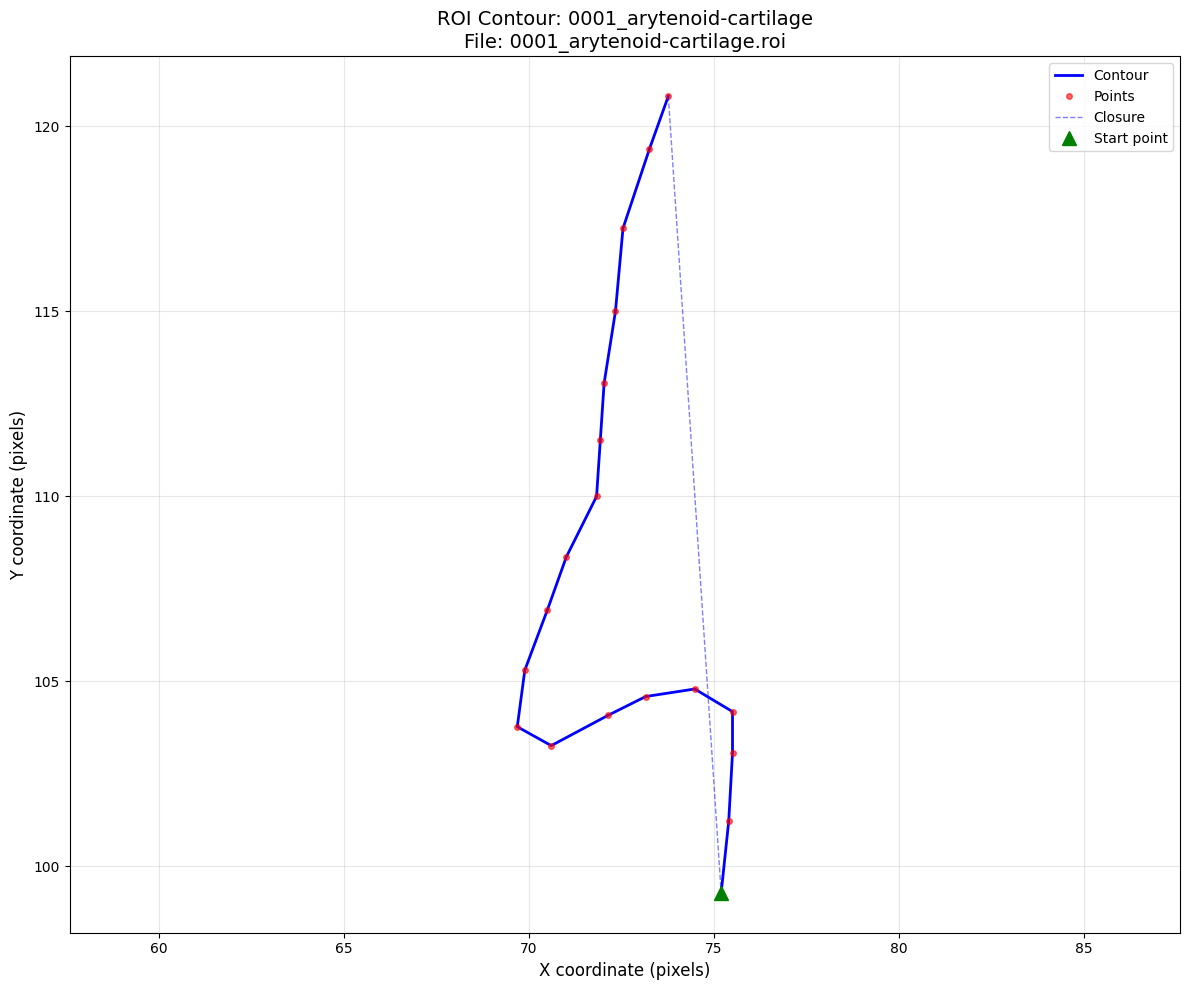


First 10 coordinates:
  Point 0: (75.20, 99.28)
  Point 1: (75.41, 101.22)
  Point 2: (75.51, 103.06)
  Point 3: (75.51, 104.18)
  Point 4: (74.49, 104.79)
  Point 5: (73.16, 104.59)
  Point 6: (72.14, 104.08)
  Point 7: (70.61, 103.26)
  Point 8: (69.69, 103.77)
  Point 9: (69.90, 105.30)


In [29]:
# Extract and visualize the contour from the ROI data
import matplotlib.pyplot as plt
import numpy as np

# Get the ROI name (usually the first and only key)
roi_name = list(roi_data.keys())[0]
roi_info = roi_data[roi_name]

print(f"\n{'='*80}")
print(f"Visualizing ROI: {roi_name}")
print(f"{'='*80}")

# Extract coordinates
if 'x' in roi_info and 'y' in roi_info:
    x_coords = np.array(roi_info['x'])
    y_coords = np.array(roi_info['y'])
    
    print(f"\nROI Type: {roi_info.get('type', 'unknown')}")
    print(f"Number of points: {len(x_coords)}")
    print(f"X range: [{x_coords.min():.2f}, {x_coords.max():.2f}]")
    print(f"Y range: [{y_coords.min():.2f}, {y_coords.max():.2f}]")
    
    # Create the plot
    plt.figure(figsize=(12, 10))
    
    # Plot the contour
    plt.plot(x_coords, y_coords, 'b-', linewidth=2, label='Contour')
    plt.plot(x_coords, y_coords, 'ro', markersize=4, label='Points', alpha=0.6)
    
    # Close the contour if it's not already closed
    if not (x_coords[0] == x_coords[-1] and y_coords[0] == y_coords[-1]):
        plt.plot([x_coords[-1], x_coords[0]], [y_coords[-1], y_coords[0]], 'b--', 
                linewidth=1, alpha=0.5, label='Closure')
    
    # Mark the first point
    plt.plot(x_coords[0], y_coords[0], 'g^', markersize=10, label='Start point')
    
    plt.xlabel('X coordinate (pixels)', fontsize=12)
    plt.ylabel('Y coordinate (pixels)', fontsize=12)
    plt.title(f'ROI Contour: {roi_name}\nFile: {os.path.basename(roi_file_path)}', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    # Print first few coordinates
    print(f"\nFirst 10 coordinates:")
    for i in range(min(10, len(x_coords))):
        print(f"  Point {i}: ({x_coords[i]:.2f}, {y_coords[i]:.2f})")
else:
    print("No x,y coordinates found in ROI data")
    print(f"Available keys: {roi_info.keys()}")

In [31]:
# Compare the same ROI file from NEW and OLD directories
# Using the same subject and session from the file we just read

subject = "1775"
session = "S6"
roi_filename = "0001_arytenoid-cartilage.roi"

# Paths to the ROI files
new_roi_path = os.path.join(new_contour_dir, subject, session, "contours", roi_filename)
old_roi_path = os.path.join(old_contour_dir, subject, session, "contours", roi_filename)

print("="*80)
print("COMPARING ROI FILES FROM NEW AND OLD DIRECTORIES")
print("="*80)
print(f"Subject: {subject}")
print(f"Session: {session}")
print(f"ROI File: {roi_filename}")
print()

# Check if both files exist
new_exists = os.path.exists(new_roi_path)
old_exists = os.path.exists(old_roi_path)

print(f"NEW directory file exists: {new_exists}")
print(f"OLD directory file exists: {old_exists}")
print()

if new_exists and old_exists:
    # Read both ROI files
    print("Reading ROI files...")
    new_roi_data = read_roi_file(new_roi_path)
    old_roi_data = read_roi_file(old_roi_path)
    
    # Get ROI names
    new_roi_name = list(new_roi_data.keys())[0]
    old_roi_name = list(old_roi_data.keys())[0]
    
    new_roi_info = new_roi_data[new_roi_name]
    old_roi_info = old_roi_data[old_roi_name]
    
    print(f"NEW ROI name: {new_roi_name}")
    print(f"OLD ROI name: {old_roi_name}")
    print()
    
    # Compare coordinates
    if 'x' in new_roi_info and 'y' in new_roi_info and 'x' in old_roi_info and 'y' in old_roi_info:
        new_x = np.array(new_roi_info['x'])
        new_y = np.array(new_roi_info['y'])
        old_x = np.array(old_roi_info['x'])
        old_y = np.array(old_roi_info['y'])
        
        print(f"NEW ROI - Number of points: {len(new_x)}")
        print(f"OLD ROI - Number of points: {len(old_x)}")
        print()
        
        # Check if they have the same number of points
        if len(new_x) == len(old_x):
            print("✓ Same number of points")
            
            # Check if coordinates are identical
            x_identical = np.allclose(new_x, old_x)
            y_identical = np.allclose(new_y, old_y)
            
            if x_identical and y_identical:
                print("✓ ✓ ✓ COORDINATES ARE IDENTICAL!")
                print("The ROI files contain exactly the same contour data.")
            else:
                print("✗ COORDINATES ARE DIFFERENT")
                
                if not x_identical:
                    max_x_diff = np.max(np.abs(new_x - old_x))
                    print(f"  X coordinates differ - Max difference: {max_x_diff:.6f}")
                    
                if not y_identical:
                    max_y_diff = np.max(np.abs(new_y - old_y))
                    print(f"  Y coordinates differ - Max difference: {max_y_diff:.6f}")
                
                # Show some differing points
                diff_mask = ~(np.isclose(new_x, old_x) & np.isclose(new_y, old_y))
                num_diff = np.sum(diff_mask)
                print(f"\nNumber of differing points: {num_diff} out of {len(new_x)}")
                
                if num_diff > 0:
                    print("\nFirst 5 differing points:")
                    diff_indices = np.where(diff_mask)[0][:5]
                    for idx in diff_indices:
                        print(f"  Point {idx}:")
                        print(f"    NEW: ({new_x[idx]:.4f}, {new_y[idx]:.4f})")
                        print(f"    OLD: ({old_x[idx]:.4f}, {old_y[idx]:.4f})")
                        print(f"    Diff: ({new_x[idx]-old_x[idx]:.4f}, {new_y[idx]-old_y[idx]:.4f})")
        else:
            print("✗ Different number of points - ROI files are NOT the same")
            print(f"  Difference: {abs(len(new_x) - len(old_x))} points")
        
        # Compare other metadata
        print("\n" + "="*80)
        print("METADATA COMPARISON")
        print("="*80)
        
        all_keys = set(new_roi_info.keys()) | set(old_roi_info.keys())
        for key in sorted(all_keys):
            if key not in ['x', 'y']:  # Already compared coordinates
                new_val = new_roi_info.get(key, 'N/A')
                old_val = old_roi_info.get(key, 'N/A')
                
                match = "✓" if new_val == old_val else "✗"
                print(f"{match} {key}:")
                print(f"    NEW: {new_val}")
                print(f"    OLD: {old_val}")
    else:
        print("Could not extract x,y coordinates from one or both ROI files")
        
else:
    if not new_exists:
        print(f"✗ File does not exist in NEW directory: {new_roi_path}")
    if not old_exists:
        print(f"✗ File does not exist in OLD directory: {old_roi_path}")

COMPARING ROI FILES FROM NEW AND OLD DIRECTORIES
Subject: 1775
Session: S6
ROI File: 0001_arytenoid-cartilage.roi

NEW directory file exists: True
OLD directory file exists: True

Reading ROI files...
NEW ROI name: 0001_arytenoid-cartilage
OLD ROI name: 0001_arytenoid-cartilage

NEW ROI - Number of points: 19
OLD ROI - Number of points: 19

✓ Same number of points
✓ ✓ ✓ COORDINATES ARE IDENTICAL!
The ROI files contain exactly the same contour data.

METADATA COMPARISON
✓ n:
    NEW: 19
    OLD: 19
✓ name:
    NEW: 0001_arytenoid-cartilage
    OLD: 0001_arytenoid-cartilage
✓ position:
    NEW: 0
    OLD: 0
✓ type:
    NEW: polyline
    OLD: polyline
✓ width:
    NEW: 0
    OLD: 0



VISUAL COMPARISON


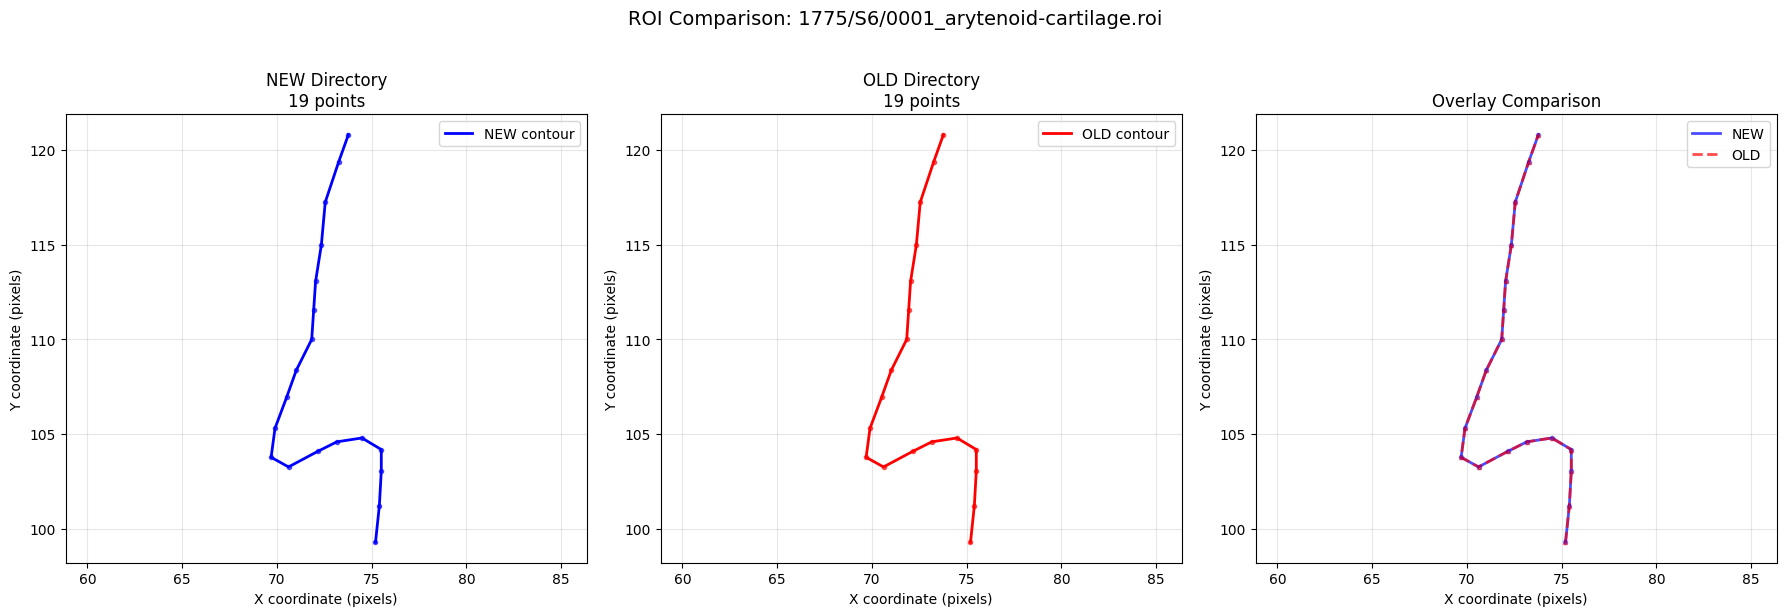


Distance statistics between corresponding points:
  Mean distance: 0.000000 pixels
  Max distance: 0.000000 pixels
  Min distance: 0.000000 pixels
  Std deviation: 0.000000 pixels

✓✓✓ CONCLUSION: Contours are IDENTICAL (all differences < 0.001 pixels)


In [32]:
# Visualize both contours overlaid for visual comparison
if new_exists and old_exists and 'x' in new_roi_info and 'y' in new_roi_info and 'x' in old_roi_info and 'y' in old_roi_info:
    print("\n" + "="*80)
    print("VISUAL COMPARISON")
    print("="*80)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: NEW contour only
    ax1 = axes[0]
    ax1.plot(new_x, new_y, 'b-', linewidth=2, label='NEW contour')
    ax1.plot(new_x, new_y, 'bo', markersize=3, alpha=0.6)
    ax1.set_xlabel('X coordinate (pixels)')
    ax1.set_ylabel('Y coordinate (pixels)')
    ax1.set_title(f'NEW Directory\n{len(new_x)} points')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')
    
    # Plot 2: OLD contour only
    ax2 = axes[1]
    ax2.plot(old_x, old_y, 'r-', linewidth=2, label='OLD contour')
    ax2.plot(old_x, old_y, 'ro', markersize=3, alpha=0.6)
    ax2.set_xlabel('X coordinate (pixels)')
    ax2.set_ylabel('Y coordinate (pixels)')
    ax2.set_title(f'OLD Directory\n{len(old_x)} points')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    
    # Plot 3: Both overlaid
    ax3 = axes[2]
    ax3.plot(new_x, new_y, 'b-', linewidth=2, label='NEW', alpha=0.7)
    ax3.plot(old_x, old_y, 'r--', linewidth=2, label='OLD', alpha=0.7)
    ax3.plot(new_x, new_y, 'bo', markersize=3, alpha=0.4)
    ax3.plot(old_x, old_y, 'r^', markersize=3, alpha=0.4)
    ax3.set_xlabel('X coordinate (pixels)')
    ax3.set_ylabel('Y coordinate (pixels)')
    ax3.set_title('Overlay Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.axis('equal')
    
    plt.suptitle(f'ROI Comparison: {subject}/{session}/{roi_filename}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Calculate statistics about the differences
    if len(new_x) == len(old_x):
        distances = np.sqrt((new_x - old_x)**2 + (new_y - old_y)**2)
        print(f"\nDistance statistics between corresponding points:")
        print(f"  Mean distance: {np.mean(distances):.6f} pixels")
        print(f"  Max distance: {np.max(distances):.6f} pixels")
        print(f"  Min distance: {np.min(distances):.6f} pixels")
        print(f"  Std deviation: {np.std(distances):.6f} pixels")
        
        if np.max(distances) < 0.001:
            print("\n✓✓✓ CONCLUSION: Contours are IDENTICAL (all differences < 0.001 pixels)")
        elif np.max(distances) < 1:
            print("\n≈ CONCLUSION: Contours are VERY SIMILAR (max difference < 1 pixel)")
        else:
            print(f"\n✗ CONCLUSION: Contours are DIFFERENT (max difference = {np.max(distances):.2f} pixels)")

In [33]:
import random

# Collect all available ROI files from sessions that exist in both directories
print("="*80)
print("COLLECTING ROI FILES FOR RANDOM SAMPLING")
print("="*80)

available_roi_files = []

for subject in sorted(common_subjects):
    old_sess = old_sessions[subject]
    new_sess = new_sessions[subject]
    
    # Only consider sessions that exist in both directories
    common_sess = old_sess & new_sess
    
    for session in common_sess:
        # Check if both have contours
        new_session_path = os.path.join(new_contour_dir, subject, session)
        old_session_path = os.path.join(old_contour_dir, subject, session)
        
        new_has_contours, new_count, new_files = check_contours_in_session(new_session_path)
        old_has_contours, old_count, old_files = check_contours_in_session(old_session_path)
        
        if new_has_contours and old_has_contours:
            # Find common ROI files
            common_roi_files = set(new_files) & set(old_files)
            
            for roi_file in common_roi_files:
                if roi_file.endswith('.roi'):
                    available_roi_files.append({
                        'subject': subject,
                        'session': session,
                        'roi_file': roi_file,
                        'new_path': os.path.join(new_contour_dir, subject, session, 'contours', roi_file),
                        'old_path': os.path.join(old_contour_dir, subject, session, 'contours', roi_file)
                    })

print(f"Found {len(available_roi_files)} ROI files in common sessions")
print()

# Sample 20 random files (or all if less than 20)
sample_size = min(20, len(available_roi_files))
sampled_files = random.sample(available_roi_files, sample_size)

print(f"Sampling {sample_size} random ROI files for comparison...")
print()

COLLECTING ROI FILES FOR RANDOM SAMPLING
Found 4220 ROI files in common sessions

Sampling 20 random ROI files for comparison...



In [34]:
# Compare the sampled ROI files
print("="*80)
print("COMPARING SAMPLED ROI FILES")
print("="*80)
print()

comparison_results = {
    'identical': [],
    'different': [],
    'errors': []
}

for idx, file_info in enumerate(sampled_files, 1):
    subject = file_info['subject']
    session = file_info['session']
    roi_file = file_info['roi_file']
    new_path = file_info['new_path']
    old_path = file_info['old_path']
    
    print(f"[{idx}/{sample_size}] Comparing: {subject}/{session}/{roi_file}")
    
    try:
        # Read both ROI files
        new_roi_data = read_roi_file(new_path)
        old_roi_data = read_roi_file(old_path)
        
        # Get ROI info
        new_roi_name = list(new_roi_data.keys())[0]
        old_roi_name = list(old_roi_data.keys())[0]
        
        new_roi_info = new_roi_data[new_roi_name]
        old_roi_info = old_roi_data[old_roi_name]
        
        # Compare coordinates
        if 'x' in new_roi_info and 'y' in new_roi_info and 'x' in old_roi_info and 'y' in old_roi_info:
            new_x = np.array(new_roi_info['x'])
            new_y = np.array(new_roi_info['y'])
            old_x = np.array(old_roi_info['x'])
            old_y = np.array(old_roi_info['y'])
            
            # Check if identical
            if len(new_x) == len(old_x):
                distances = np.sqrt((new_x - old_x)**2 + (new_y - old_y)**2)
                max_distance = np.max(distances)
                
                if max_distance < 0.001:
                    comparison_results['identical'].append(file_info)
                    print(f"  ✓ IDENTICAL (max distance: {max_distance:.10f} pixels)")
                else:
                    comparison_results['different'].append({
                        **file_info,
                        'max_distance': max_distance,
                        'mean_distance': np.mean(distances),
                        'num_points': len(new_x)
                    })
                    print(f"  ✗ DIFFERENT (max distance: {max_distance:.6f} pixels, mean: {np.mean(distances):.6f})")
            else:
                comparison_results['different'].append({
                    **file_info,
                    'new_points': len(new_x),
                    'old_points': len(old_x),
                    'reason': 'different_point_count'
                })
                print(f"  ✗ DIFFERENT (NEW: {len(new_x)} points, OLD: {len(old_x)} points)")
        else:
            comparison_results['errors'].append({
                **file_info,
                'error': 'missing_coordinates'
            })
            print(f"  ⚠️  ERROR: Missing x,y coordinates")
    
    except Exception as e:
        comparison_results['errors'].append({
            **file_info,
            'error': str(e)
        })
        print(f"  ⚠️  ERROR: {e}")
    
    print()

# Print summary
print("="*80)
print("COMPARISON SUMMARY")
print("="*80)
print(f"Total sampled: {sample_size}")
print(f"✓ Identical: {len(comparison_results['identical'])} ({len(comparison_results['identical'])/sample_size*100:.1f}%)")
print(f"✗ Different: {len(comparison_results['different'])} ({len(comparison_results['different'])/sample_size*100:.1f}%)")
print(f"⚠️  Errors: {len(comparison_results['errors'])} ({len(comparison_results['errors'])/sample_size*100:.1f}%)")
print()

if comparison_results['different']:
    print("="*80)
    print("DETAILS OF DIFFERENT FILES")
    print("="*80)
    for item in comparison_results['different']:
        print(f"\n{item['subject']}/{item['session']}/{item['roi_file']}")
        if 'max_distance' in item:
            print(f"  Max distance: {item['max_distance']:.6f} pixels")
            print(f"  Mean distance: {item['mean_distance']:.6f} pixels")
            print(f"  Number of points: {item['num_points']}")
        elif 'reason' in item and item['reason'] == 'different_point_count':
            print(f"  NEW points: {item['new_points']}")
            print(f"  OLD points: {item['old_points']}")

if comparison_results['errors']:
    print("\n" + "="*80)
    print("ERRORS")
    print("="*80)
    for item in comparison_results['errors']:
        print(f"\n{item['subject']}/{item['session']}/{item['roi_file']}")
        print(f"  Error: {item['error']}")

COMPARING SAMPLED ROI FILES

[1/20] Comparing: 1775/S13/3718_thyroid-cartilage.roi
  ✓ IDENTICAL (max distance: 0.0000000000 pixels)

[2/20] Comparing: 1775/S17/3868_arytenoid-cartilage.roi
  ✓ IDENTICAL (max distance: 0.0000000000 pixels)

[3/20] Comparing: 1775/S8/0012_thyroid-cartilage.roi
  ✓ IDENTICAL (max distance: 0.0000000000 pixels)

[4/20] Comparing: 1775/S29/0108_upper-lip.roi
  ✓ IDENTICAL (max distance: 0.0000000000 pixels)

[5/20] Comparing: 1775/S19/0922_epiglottis.roi
  ✓ IDENTICAL (max distance: 0.0000000000 pixels)

[6/20] Comparing: 1775/S13/2230_thyroid-cartilage.roi
  ✓ IDENTICAL (max distance: 0.0000000000 pixels)

[7/20] Comparing: 1775/S7/1551_pharynx.roi
  ✓ IDENTICAL (max distance: 0.0000000000 pixels)

[8/20] Comparing: 1775/S6/0536_upper-lip.roi
  ✓ IDENTICAL (max distance: 0.0000000000 pixels)

[9/20] Comparing: 1775/S13/0295_upper-lip.roi
  ✓ IDENTICAL (max distance: 0.0000000000 pixels)

[10/20] Comparing: 1775/S17/0010_soft-palate-midline.roi
  ✓ IDENTIC

In [35]:
# Define the two directories to check
artspeech_db2 = "/srv/storage/talc@storage4.nancy/multispeech/corpus/speech_production/iadi/ArtSpeech_Database_2"
artspeech_vts = "/srv/storage/talc@storage4.nancy/multispeech/corpus/speech_production/iadi/ArtSpeech_Vocal_Tract_Segmentation"

print("="*80)
print("CHECKING DIRECTORY STRUCTURE")
print("="*80)
print(f"Directory 1: {artspeech_db2}")
print(f"Directory 2: {artspeech_vts}")
print()

def check_session_structure(session_path):
    """
    Check what subdirectories exist in a session directory.
    Returns a dict with boolean flags for each common subdirectory.
    """
    structure = {
        'contours': False,
        'masks': False,
        'images': False,
        'dicom': False,
        'mhd': False,
        'other_dirs': []
    }
    
    if not os.path.exists(session_path):
        return structure
    
    try:
        items = os.listdir(session_path)
        for item in items:
            item_path = os.path.join(session_path, item)
            if os.path.isdir(item_path):
                item_lower = item.lower()
                if 'contour' in item_lower:
                    structure['contours'] = True
                elif 'mask' in item_lower:
                    structure['masks'] = True
                elif 'image' in item_lower:
                    structure['images'] = True
                elif 'dicom' in item_lower:
                    structure['dicom'] = True
                elif 'mhd' in item_lower:
                    structure['mhd'] = True
                else:
                    structure['other_dirs'].append(item)
    except PermissionError:
        pass
    
    return structure

# Collect session structures from both directories
session_structures_db2 = {}
session_structures_vts = {}

print("Scanning ArtSpeech_Database_2...")
if os.path.exists(artspeech_db2):
    for subject in os.listdir(artspeech_db2):
        subject_path = os.path.join(artspeech_db2, subject)
        if os.path.isdir(subject_path):
            for session in os.listdir(subject_path):
                session_path = os.path.join(subject_path, session)
                if os.path.isdir(session_path):
                    key = f"{subject}/{session}"
                    session_structures_db2[key] = check_session_structure(session_path)
    print(f"  Found {len(session_structures_db2)} sessions")
else:
    print(f"  Directory does not exist!")

print("\nScanning ArtSpeech_Vocal_Tract_Segmentation...")
if os.path.exists(artspeech_vts):
    for subject in os.listdir(artspeech_vts):
        subject_path = os.path.join(artspeech_vts, subject)
        if os.path.isdir(subject_path):
            for session in os.listdir(subject_path):
                session_path = os.path.join(subject_path, session)
                if os.path.isdir(session_path):
                    key = f"{subject}/{session}"
                    session_structures_vts[key] = check_session_structure(session_path)
    print(f"  Found {len(session_structures_vts)} sessions")
else:
    print(f"  Directory does not exist!")

print()

CHECKING DIRECTORY STRUCTURE
Directory 1: /srv/storage/talc@storage4.nancy/multispeech/corpus/speech_production/iadi/ArtSpeech_Database_2
Directory 2: /srv/storage/talc@storage4.nancy/multispeech/corpus/speech_production/iadi/ArtSpeech_Vocal_Tract_Segmentation

Scanning ArtSpeech_Database_2...
  Found 178 sessions

Scanning ArtSpeech_Vocal_Tract_Segmentation...
  Found 160 sessions



In [36]:
# Analyze sessions with contours and check for masks/other directories
print("="*80)
print("ANALYSIS: SESSIONS WITH CONTOURS")
print("="*80)
print()

# ArtSpeech_Database_2 analysis
print("--- ArtSpeech_Database_2 ---")
db2_with_contours = {k: v for k, v in session_structures_db2.items() if v['contours']}
db2_with_contours_and_masks = {k: v for k, v in db2_with_contours.items() if v['masks']}
db2_with_contours_no_masks = {k: v for k, v in db2_with_contours.items() if not v['masks']}

print(f"Sessions with contours: {len(db2_with_contours)}")
print(f"  - With masks: {len(db2_with_contours_and_masks)} ({len(db2_with_contours_and_masks)/len(db2_with_contours)*100:.1f}%)")
print(f"  - Without masks: {len(db2_with_contours_no_masks)} ({len(db2_with_contours_no_masks)/len(db2_with_contours)*100:.1f}%)")

# Check what other directories exist
db2_other_dirs_summary = {}
for session, structure in db2_with_contours.items():
    for key in ['images', 'dicom', 'mhd']:
        if structure[key]:
            if key not in db2_other_dirs_summary:
                db2_other_dirs_summary[key] = 0
            db2_other_dirs_summary[key] += 1
    for other in structure['other_dirs']:
        if other not in db2_other_dirs_summary:
            db2_other_dirs_summary[other] = 0
        db2_other_dirs_summary[other] += 1

print(f"\nOther directories found in sessions with contours:")
for dir_name, count in sorted(db2_other_dirs_summary.items(), key=lambda x: -x[1]):
    print(f"  - {dir_name}: {count} sessions ({count/len(db2_with_contours)*100:.1f}%)")

print()
print("--- ArtSpeech_Vocal_Tract_Segmentation ---")
vts_with_contours = {k: v for k, v in session_structures_vts.items() if v['contours']}
vts_with_contours_and_masks = {k: v for k, v in vts_with_contours.items() if v['masks']}
vts_with_contours_no_masks = {k: v for k, v in vts_with_contours.items() if not v['masks']}

print(f"Sessions with contours: {len(vts_with_contours)}")
print(f"  - With masks: {len(vts_with_contours_and_masks)} ({len(vts_with_contours_and_masks)/len(vts_with_contours)*100:.1f}%)")
print(f"  - Without masks: {len(vts_with_contours_no_masks)} ({len(vts_with_contours_no_masks)/len(vts_with_contours)*100:.1f}%)")

# Check what other directories exist
vts_other_dirs_summary = {}
for session, structure in vts_with_contours.items():
    for key in ['images', 'dicom', 'mhd']:
        if structure[key]:
            if key not in vts_other_dirs_summary:
                vts_other_dirs_summary[key] = 0
            vts_other_dirs_summary[key] += 1
    for other in structure['other_dirs']:
        if other not in vts_other_dirs_summary:
            vts_other_dirs_summary[other] = 0
        vts_other_dirs_summary[other] += 1

print(f"\nOther directories found in sessions with contours:")
for dir_name, count in sorted(vts_other_dirs_summary.items(), key=lambda x: -x[1]):
    print(f"  - {dir_name}: {count} sessions ({count/len(vts_with_contours)*100:.1f}%)")

ANALYSIS: SESSIONS WITH CONTOURS

--- ArtSpeech_Database_2 ---
Sessions with contours: 178
  - With masks: 26 (14.6%)
  - Without masks: 152 (85.4%)

Other directories found in sessions with contours:
  - NPY_MR: 178 sessions (100.0%)
  - NPY_MR_registered: 165 sessions (92.7%)
  - air_column: 138 sessions (77.5%)

--- ArtSpeech_Vocal_Tract_Segmentation ---
Sessions with contours: 159
  - With masks: 159 (100.0%)
  - Without masks: 0 (0.0%)

Other directories found in sessions with contours:
  - dicom: 159 sessions (100.0%)
  - NPY_MR: 159 sessions (100.0%)


In [37]:
# Show detailed information about sessions with contours but no masks
print("\n" + "="*80)
print("SESSIONS WITH CONTOURS BUT NO MASKS")
print("="*80)

if db2_with_contours_no_masks:
    print(f"\nArtSpeech_Database_2 ({len(db2_with_contours_no_masks)} sessions):")
    for session, structure in sorted(db2_with_contours_no_masks.items())[:20]:  # Show first 20
        dirs_present = []
        if structure['images']:
            dirs_present.append('images')
        if structure['dicom']:
            dirs_present.append('dicom')
        if structure['mhd']:
            dirs_present.append('mhd')
        dirs_present.extend(structure['other_dirs'])
        
        print(f"  {session}")
        print(f"    Directories: contours, {', '.join(dirs_present) if dirs_present else 'none'}")
    
    if len(db2_with_contours_no_masks) > 20:
        print(f"  ... and {len(db2_with_contours_no_masks) - 20} more")
else:
    print("\nArtSpeech_Database_2: All sessions with contours also have masks ✓")

if vts_with_contours_no_masks:
    print(f"\nArtSpeech_Vocal_Tract_Segmentation ({len(vts_with_contours_no_masks)} sessions):")
    for session, structure in sorted(vts_with_contours_no_masks.items())[:20]:  # Show first 20
        dirs_present = []
        if structure['images']:
            dirs_present.append('images')
        if structure['dicom']:
            dirs_present.append('dicom')
        if structure['mhd']:
            dirs_present.append('mhd')
        dirs_present.extend(structure['other_dirs'])
        
        print(f"  {session}")
        print(f"    Directories: contours, {', '.join(dirs_present) if dirs_present else 'none'}")
    
    if len(vts_with_contours_no_masks) > 20:
        print(f"  ... and {len(vts_with_contours_no_masks) - 20} more")
else:
    print("\nArtSpeech_Vocal_Tract_Segmentation: All sessions with contours also have masks ✓")

# Create a comparison summary
print("\n" + "="*80)
print("COMPARISON SUMMARY")
print("="*80)
print(f"\n{'Metric':<50} {'DB2':<15} {'VTS':<15}")
print("-"*80)
print(f"{'Total sessions':<50} {len(session_structures_db2):<15} {len(session_structures_vts):<15}")
print(f"{'Sessions with contours':<50} {len(db2_with_contours):<15} {len(vts_with_contours):<15}")
print(f"{'Sessions with contours AND masks':<50} {len(db2_with_contours_and_masks):<15} {len(vts_with_contours_and_masks):<15}")
print(f"{'Sessions with contours but NO masks':<50} {len(db2_with_contours_no_masks):<15} {len(vts_with_contours_no_masks):<15}")

if len(db2_with_contours) > 0:
    print(f"{'% with masks (of those with contours)':<50} {len(db2_with_contours_and_masks)/len(db2_with_contours)*100:.1f}%{' ':<10} {len(vts_with_contours_and_masks)/len(vts_with_contours)*100:.1f}%{' ':<10}")


SESSIONS WITH CONTOURS BUT NO MASKS

ArtSpeech_Database_2 (152 sessions):
  1775/S25
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S33
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S34
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S35
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S36
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S37
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S38
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S39
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S40
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S41
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S42
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1775/S43
    Directories: contours, air_column, NPY_MR_registered, NPY_MR
  1777/S13
  